In [1]:
import sys
# append the path of the parent directory
sys.path.append("..")

In [2]:
import math
import os
import time


import numpy as np
np.set_printoptions(legacy='1.25')

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches

import seaborn as sns
import time
import json
import pandas as pd
from ctypes import c_int32
from itertools import product
import copy


from tqdm import tqdm

from scipy.stats import pearsonr
from importlib import reload

import orjson
import gzip

from scipy.stats import entropy
from pympler import asizeof

from lib import sketches, visualization_utils, encoders, ploting, pacha_sketch, experiment_utils
reload(ploting)
reload(sketches)
reload(visualization_utils)
reload(encoders)

reload(pacha_sketch)
reload(experiment_utils)

from lib.experiment_utils import add_true_results, compute_true_counts

from lib.sketches import BloomFilter, CountMinSketch, H3HashFunctions, HashFunctionFamily,\
      CountMinSketchHadamard, CountMinSketchLocalHashing, deterministic_hash, simple_deterministic_hash, \
      fast_hash_xx
from lib.visualization_utils import plot_boxplot, plot_relative_error

from lib.encoders import minimal_b_adic_cover, minimal_spatial_b_adic_cover, BAdicCube, BAdicRange, \
      minimal_b_adic_cover_array, downgrade_b_adic_range_indices
from lib.pacha_sketch import PachaSketch, ADTree, BFParameters, CMParameters, \
      cartesian_product, get_n_updates, MaterializedCombinations, get_n_updates_customized

from lib.ploting import set_style, plot_ylabel, plot_legend

from lib import baselines
reload(baselines)

from lib.baselines import CentralDPServer, LDPServer, LDPEncoderGRR, filter_df, query_df, \
      infer_domains_and_ranges, translate_query_region, evaluate_queries, check_accruracy, \
      evaluate_queries_baselines, evaluate_equivalent_pacha_sketches, compute_relative_entropy

# set_style()

/home/rudi/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


# Forced Alignment

# Pacha Sketch: Java vs Python

In [35]:
dataset_name = "tpch"
folder = "omni/"
len_df = 599_934
n_cat = 5
n_num = 5

path_to_estimates = f"../results/{folder}{dataset_name}/{dataset_name}_random.csv"
path_to_true_counts = f"../results/python/{dataset_name}/{dataset_name}_random.csv"
add_true_results(path_to_estimates, path_to_true_counts, len_df)

selectivities = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
for sel in selectivities:
    path_to_estimates = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    path_to_estimates = f"../results/{folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_nums = np.arange(1, n_num+1)
for n in n_nums:
    path_to_estimates = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    path_to_estimates = f"../results/{folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


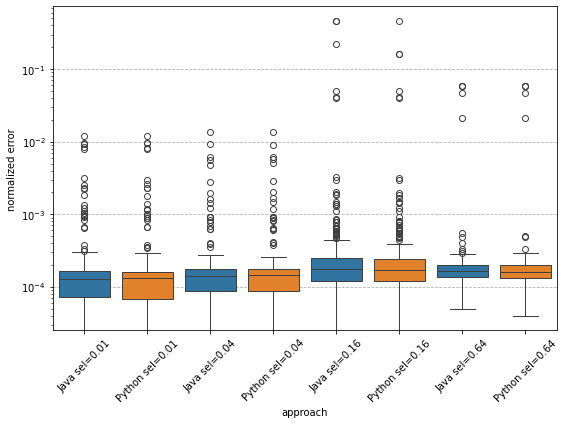

In [7]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Java', '', 'tab:blue'), ('Python', 'python/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={sel}"
            dfs.append(df)
            approaches.append((f"{impl} sel={sel}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


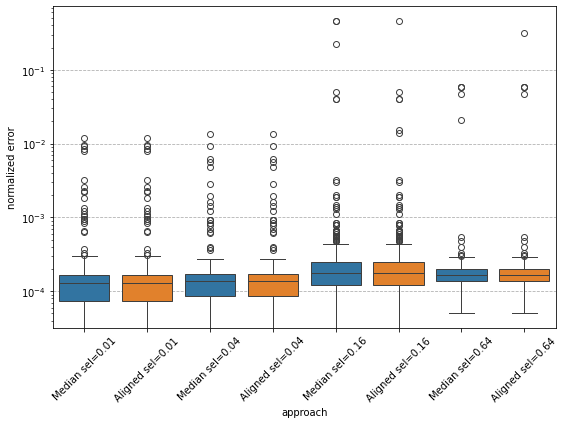

In [16]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Median', '', 'tab:blue'), ('Aligned', 'pachaAl/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={sel}"
            dfs.append(df)
            approaches.append((f"{impl} sel={sel}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


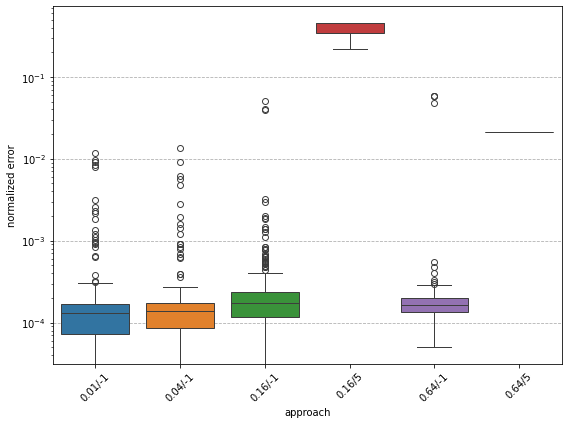

In [18]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Java', '', 'tab:blue')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = [f"{sel}/{forced}" for forced in df['forced']]
            dfs.append(df)
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


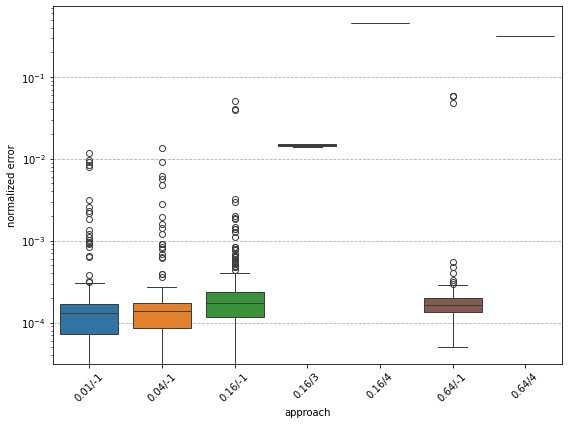

In [19]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Java', 'pachaAl/', 'tab:blue')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = [f"{sel}/{forced}" for forced in df['forced']]
            dfs.append(df)
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


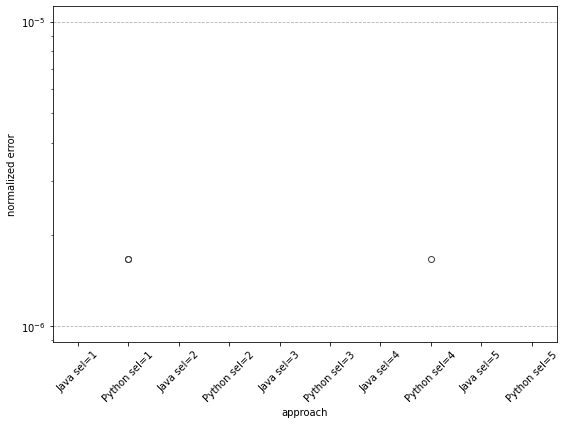

In [ ]:
dfs = []
approaches = []
n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    for impl, folder, color in [('Java', '', 'tab:blue'), ('Python', 'python/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={n}"
            dfs.append(df)
            approaches.append((f"{impl} sel={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

In [27]:
path = f"../results/pachaAl/{dataset_name}/numerical/{dataset_name}_num_{3}.csv"
df = pd.read_csv(path)

In [30]:
df['forced'].value_counts()

forced
2    188
1     12
Name: count, dtype: int64

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


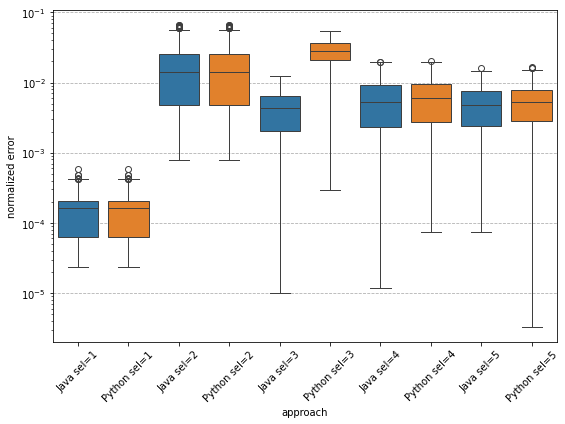

In [21]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Java', '', 'tab:blue'), ('Python', 'pachaAl/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={n}"
            dfs.append(df)
            approaches.append((f"{impl} sel={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


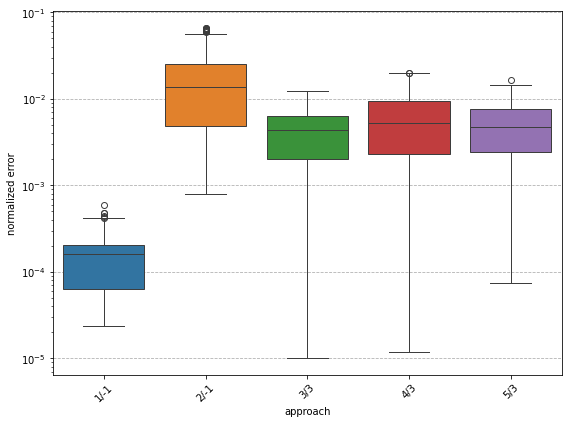

In [12]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Java', '', 'tab:blue')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = [f"{n}/{forced}" for forced in df['forced']]
            dfs.append(df)
        except Exception as e:
            print(f"Could not load {path}: {e}")

fig = plot_boxplot(dfs, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


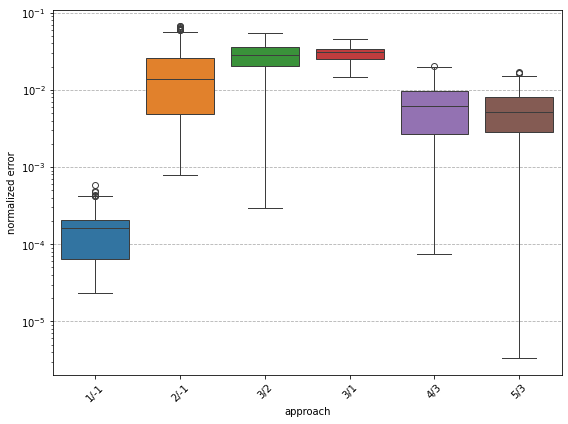

In [20]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Java', 'pachaAl/', 'tab:blue')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = [f"{n}/{forced}" for forced in df['forced']]
            dfs.append(df)
        except Exception as e:
            print(f"Could not load {path}: {e}")

fig = plot_boxplot(dfs, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


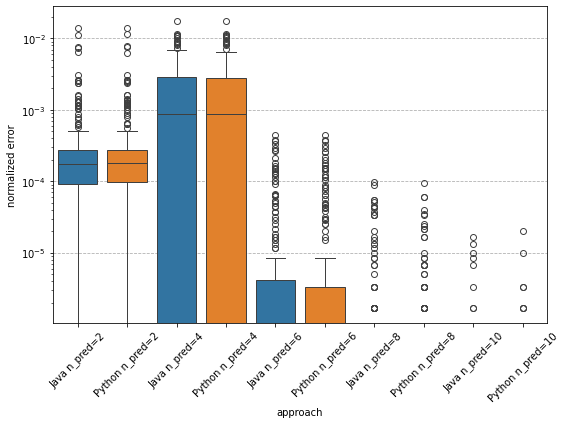

In [23]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Java', '', 'tab:blue'), ('Python', 'python/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={2*n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={2*n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

# Omni vs Pacha

In [11]:
dataset_name = "tpch"
len_df = 599_934
n_cat = 5
n_num = 5

path_to_estimates = f"../results/omni/{dataset_name}/{dataset_name}_random.csv"
path_to_true_counts = f"../results/python/{dataset_name}/{dataset_name}_random.csv"
add_true_results(path_to_estimates, path_to_true_counts, len_df)

selectivities = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
for sel in selectivities:
    path_to_estimates = f"../results/omni/{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    path_to_estimates = f"../results/omni/{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_nums = np.arange(1, n_num+1)
for n in n_nums:
    path_to_estimates = f"../results/omni/{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    path_to_estimates = f"../results/omni/{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
    path_to_true_counts = f"../results/python/{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
    add_true_results(path_to_estimates, path_to_true_counts, len_df)

In [3]:
len_df = 599_934
results_folder = "../results/omni3/"
dataset_name = "tpch"

path_to_estimates = f"{results_folder}{dataset_name}/tpch_random.csv"
path_to_true_counts = f"../results/python/{dataset_name}/{dataset_name}_random.csv"
add_true_results(path_to_estimates, path_to_true_counts, len_df)

,estimates,runtime,case,baseline_runtimes,true_counts,absolute_error,normalized_error,relative_error
0,141547,11342.5566,2,0.078877,80043,61504,0.102518,0.768387
1,24804,3185.0515,2,0.042778,38619,13815,0.023028,0.357725
2,136323,16223.0920,2,0.022937,94973,41350,0.068924,0.435387
3,9885,9329.8528,1,0.032374,5464,4421,0.007369,0.809114
4,20155,2876.7089,1,0.029234,21726,1571,0.002619,0.072310
...,...,...,...,...,...,...,...,...
195,13981,2041.0883,1,0.030443,21408,7427,0.012380,0.346926
196,114086,14527.7166,2,0.022496,28760,85326,0.142226,2.966829
197,18855,2199.5729,1,0.030416,21408,2553,0.004255,0.119254
198,135135,12892.1588,2,0.023561,35918,99217,0.165380,2.762320


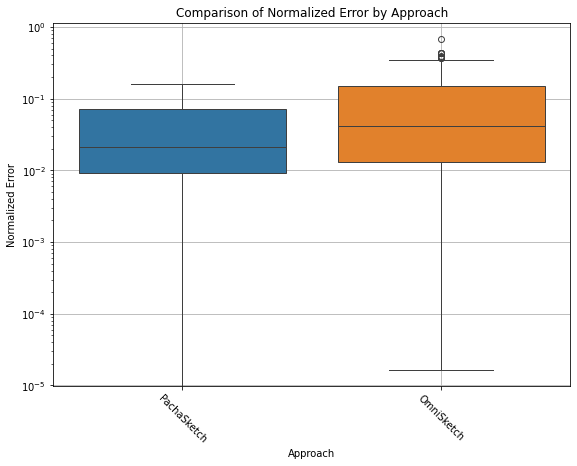

In [6]:
path_to_pacha = "../results/omni2/tpch/tpch_random.csv"
path_to_omni = "../results/omni3/tpch/tpch_random.csv"
len_df = 599_934

pacha_results = pd.read_csv(path_to_pacha)
omni_results = pd.read_csv(path_to_omni)

pacha_results['approach'] = 'PachaSketch'
omni_results['approach'] = 'OmniSketch'

plot_normalized_error_boxplot([pacha_results, omni_results])

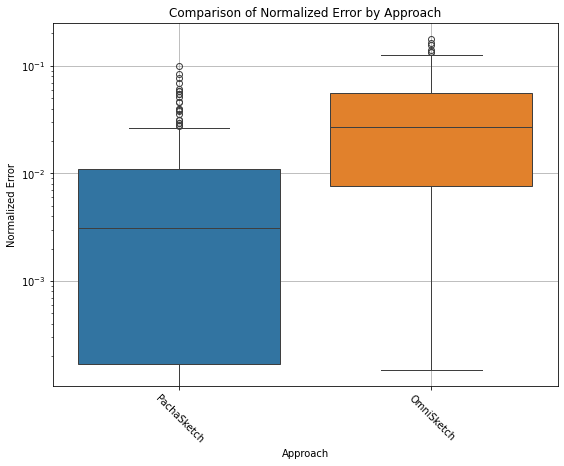

In [13]:
path_to_pacha = "../results/tpch/tpch_random.csv"
path_to_omni = "../results/omni/tpch/tpch_random.csv"
len_df = 599_934

pacha_results = pd.read_csv(path_to_pacha)
omni_results = pd.read_csv(path_to_omni)

pacha_results['approach'] = 'PachaSketch'
omni_results['approach'] = 'OmniSketch'

plot_normalized_error_boxplot([pacha_results, omni_results])

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


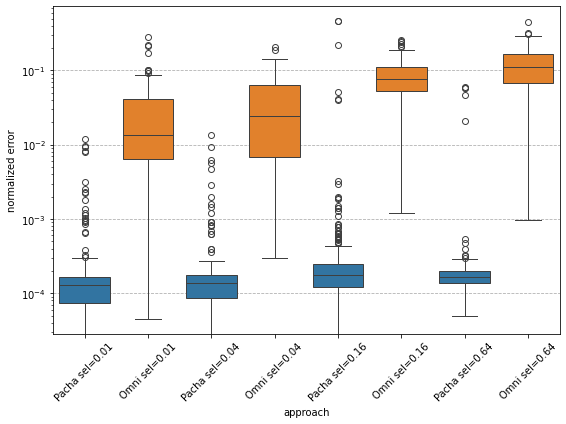

In [15]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={sel}"
            dfs.append(df)
            approaches.append((f"{impl} sel={sel}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


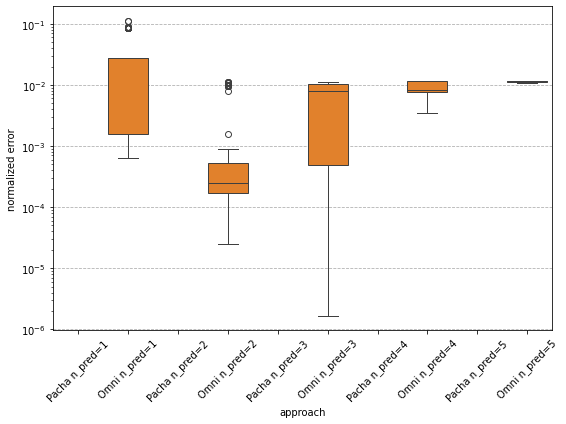

In [18]:
dfs = []
approaches = []
n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


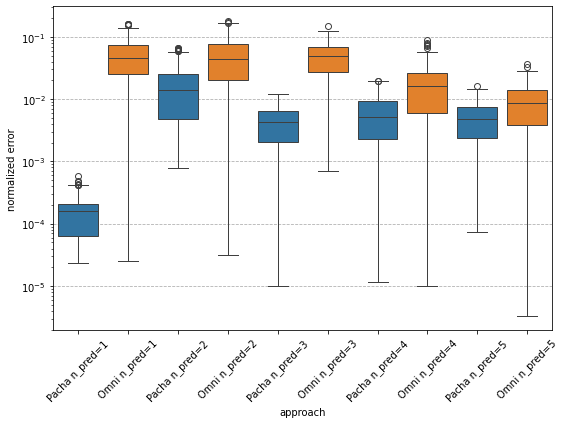

In [19]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


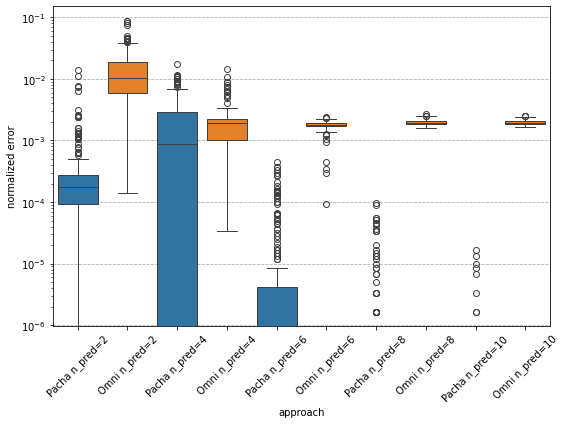

In [21]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={2*n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={2*n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

# Omni vs Pacha

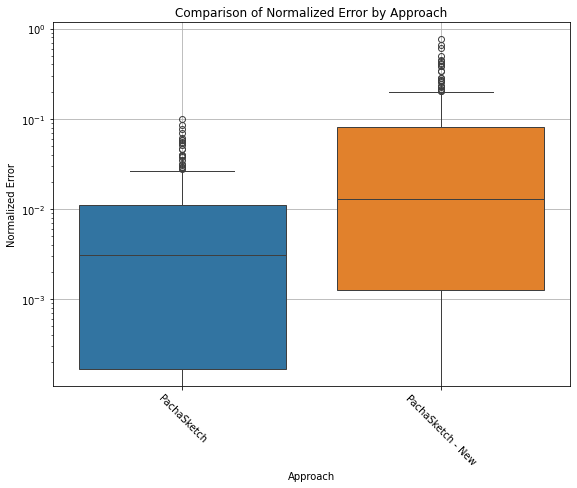

In [13]:
path_to_pacha = "../results/tpch/tpch_random.csv"
path_to_omni = "../results/pachaG/tpch/tpch_random.csv"
len_df = 599_934

pacha_results = pd.read_csv(path_to_pacha)
omni_results = pd.read_csv(path_to_omni)

pacha_results['approach'] = 'PachaSketch'
omni_results['approach'] = 'PachaSketch - New'

plot_normalized_error_boxplot([pacha_results, omni_results])

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


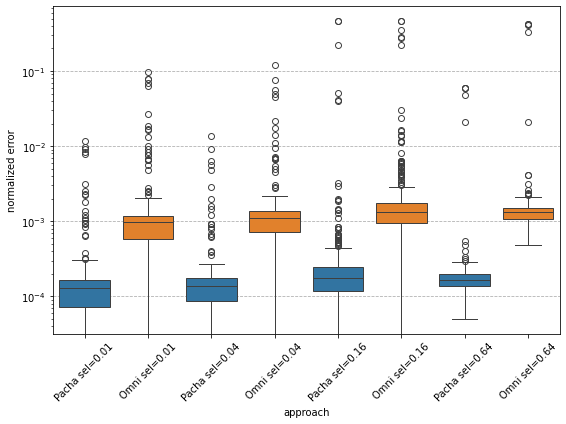

In [14]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'pachaG/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={sel}"
            dfs.append(df)
            approaches.append((f"{impl} sel={sel}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


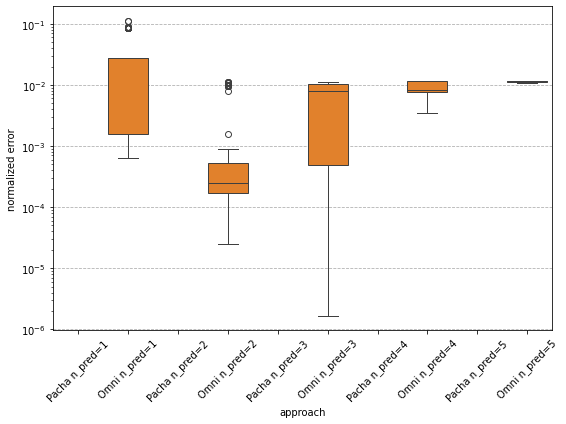

In [ ]:
dfs = []
approaches = []
n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


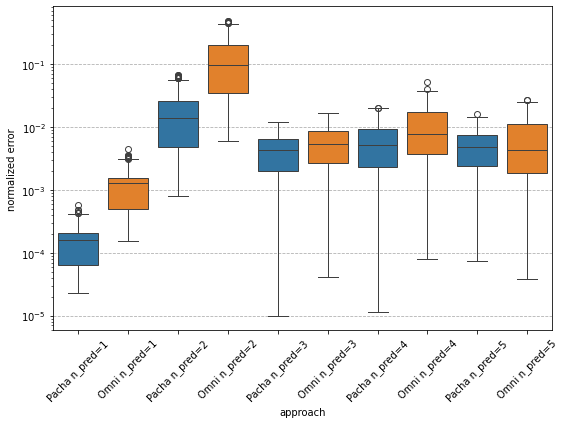

In [15]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'pachaG/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


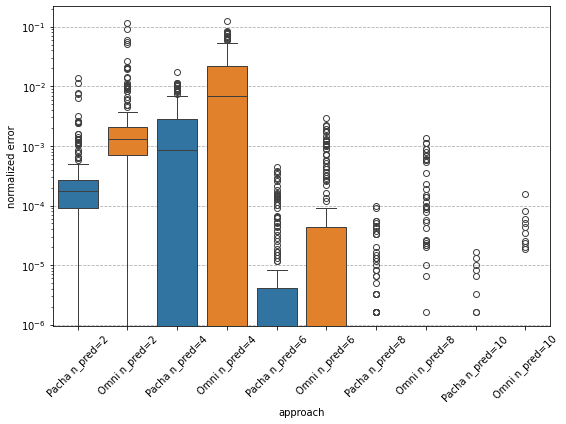

In [16]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Pacha', '', 'tab:blue'), ('Omni', 'pachaG/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={2*n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={2*n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

# Omni vs Omni New

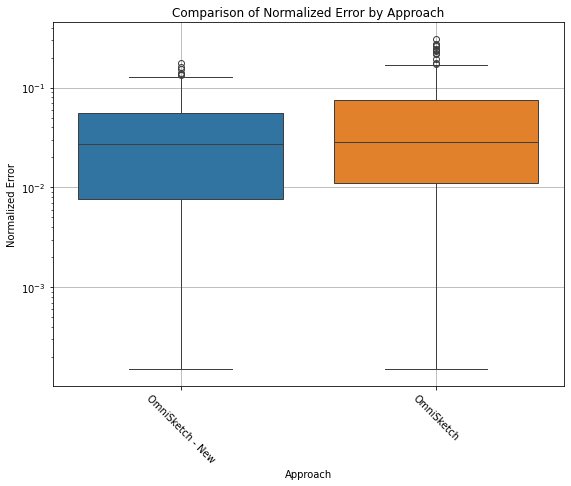

In [36]:
path_to_pacha = "../results/omniNew/tpch/tpch_random.csv"
path_to_omni = "../results/omni/tpch/tpch_random.csv"
len_df = 599_934

pacha_results = pd.read_csv(path_to_pacha)
omni_results = pd.read_csv(path_to_omni)

pacha_results['approach'] = 'OmniSketch - New'
omni_results['approach'] = 'OmniSketch'

plot_normalized_error_boxplot([pacha_results, omni_results])

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


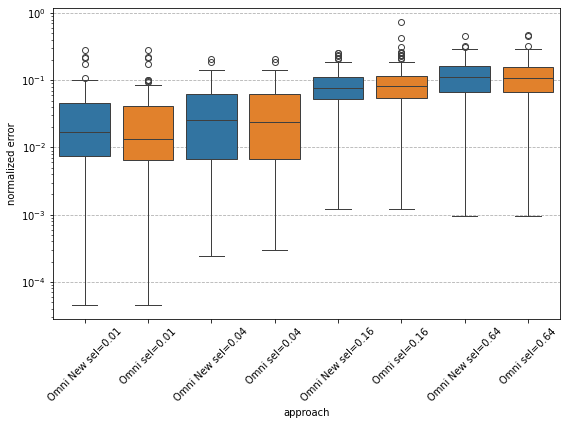

In [37]:
dfs = []
approaches = []
selectivities = np.array([0.01, 0.04, 0.16, 0.64])
for sel in selectivities:
    for impl, folder, color in [('Omni New', 'omniNew/', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/selectivities/{dataset_name}_sel_{sel}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} sel={sel}"
            dfs.append(df)
            approaches.append((f"{impl} sel={sel}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


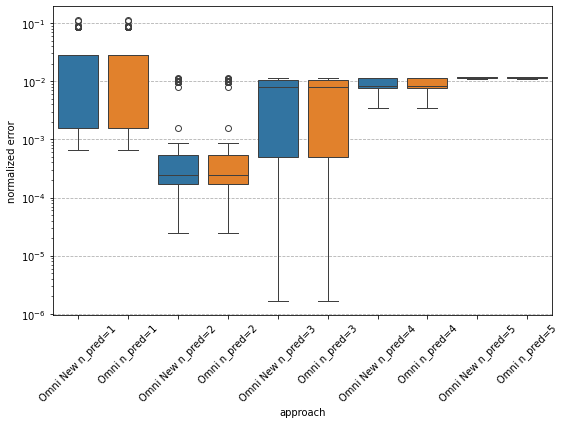

In [38]:
dfs = []
approaches = []
n_cats = np.arange(1, n_cat+1)
for n in n_cats:
    for impl, folder, color in [('Omni New', 'omniNew/', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/categorical/{dataset_name}_cat_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


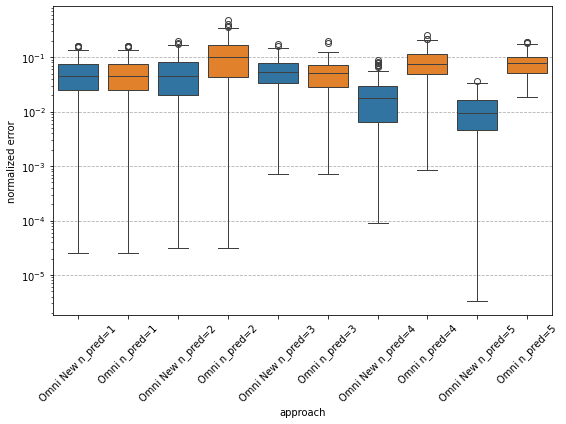

In [39]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Omni New', 'omniNew/', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/numerical/{dataset_name}_num_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

/mnt/c/Users/rpoepsel/Documents/PhD/0-Artifacts/pacha_sketch_prototype/experiments/../lib/visualization_utils.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='center')


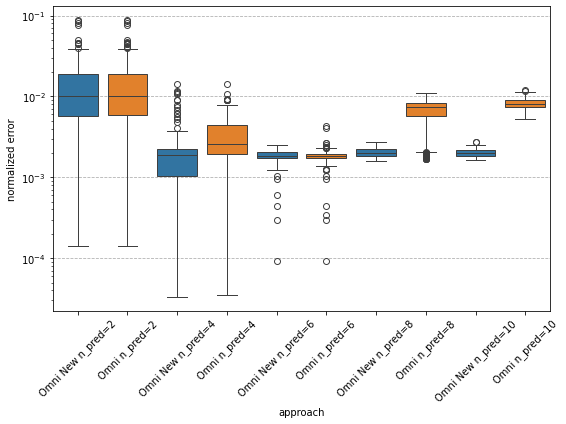

In [40]:
dfs = []
approaches = []
n_diminant = max(n_cat, n_num)
n_mix = np.arange(1, n_diminant+1)
for n in n_mix:
    for impl, folder, color in [('Omni New', 'omniNew/', 'tab:blue'), ('Omni', 'omni/', 'tab:orange')]:
        path = f"../results/{folder}{dataset_name}/mixed/{dataset_name}_mix_{n}.csv"
        try:
            df = pd.read_csv(path)
            df['approach'] = f"{impl} n_pred={2*n}"
            dfs.append(df)
            approaches.append((f"{impl} n_pred={2*n}", color))
        except Exception as e:
            print(f"Could not load {path}: {e}")

palette = {name: color for name, color in approaches}
fig = plot_boxplot(dfs, palette=palette, log_scale=True, rotation=45)

# Playground

In [ ]:
path_to_estimates = "../results/tpch/tpch_random.csv"
path_to_true_counts = "../results/python/tpch/tpch_random.csv"
len_df = 599_934

java_results = add_true_results(path_to_estimates, path_to_true_counts, len_df)

In [5]:
def plot_normalized_error_boxplot(dfs, palette=None):
    # Add 'approach' column if missing (assumes each df has a unique approach)
    for df in dfs:
        if 'approach' not in df.columns:
            raise ValueError("Each DataFrame must have an 'approach' column.")

    combined_df = pd.concat(dfs, ignore_index=True)
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='approach', y='normalized_error', hue='approach', data=combined_df, palette=palette)
    plt.xlabel('Approach')
    plt.ylabel('Normalized Error')
    plt.title('Comparison of Normalized Error by Approach')
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xticks(rotation=-45)
    plt.show()

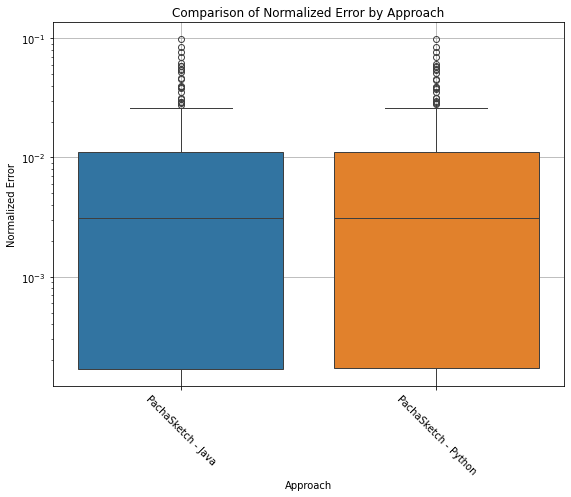

In [71]:
python_results = pd.read_csv(path_to_true_counts)

java_results['approach'] = 'PachaSketch - Java'
python_results['approach'] = 'PachaSketch - Python'

plot_normalized_error_boxplot([java_results, python_results])

In [72]:
print(f"Java: {compute_relative_entropy(java_results)}")
print(f"Python: {compute_relative_entropy(python_results)}")

Java: 0.013686460922499404
Python: 0.01365377661366069


In [15]:
java_results.columns

Index(['estimates', 'relevant_nodes', 'cat_regions', 'b_adic_cubes',
       'num_regions', 'candidate_regions', 'query_regions', 'level_0_queries',
       'level_1_queries', 'level_2_queries', 'level_3_queries',
       'level_4_queries', 'baseline_runtimes', 'true_counts', 'absolute_error',
       'normalized_error', 'relative_error', 'total_sketch_queries',
       'approach'],
      dtype='object')

In [68]:
columns = ['relevant_nodes', 'cat_regions', 'b_adic_cubes',
       'num_regions', 'candidate_regions', 'query_regions', 'total_sketch_queries']
column_name = columns[-1]

print(column_name)
print(java_results[column_name].describe())
print(python_results[column_name].describe())

print((java_results["absolute_error"].sum() - python_results["absolute_error"].sum())/200)



total_sketch_queries
count       200.000000
mean      11114.130000
std       25522.201559
min           4.000000
25%          52.000000
50%        2086.500000
75%        7513.000000
max      146258.000000
Name: total_sketch_queries, dtype: float64
count       200.000000
mean      11115.425000
std       25521.636851
min          10.000000
25%          52.000000
50%        2086.500000
75%        7513.000000
max      146258.000000
Name: total_sketch_queries, dtype: float64
13.335


In [69]:
13.335 / len_df

2.2227445018952088e-05

In [73]:
pivot_df = java_results.copy()
pivot_df = pivot_df[["b_adic_cubes"]]
pivot_df['b_adic_cubes_2'] = python_results["b_adic_cubes"].copy()
pivot_df['diff'] = pivot_df['b_adic_cubes'] - pivot_df['b_adic_cubes_2']
errors = pivot_df[pivot_df['diff'] != 0]
print(len(errors))
errors


13


,b_adic_cubes,b_adic_cubes_2,diff
11,1,5,-4
26,1,5,-4
68,1,5,-4
78,1,5,-4
82,1,5,-4
83,1,5,-4
105,1,5,-4
119,1,5,-4
120,1,5,-4
121,1,5,-4


In [65]:
java_results[pivot_df['diff'] != 0]["absolute_error"]

11     0
26     0
68     0
78     0
82     0
83     0
105    0
119    0
120    0
121    0
140    0
172    0
186    0
Name: absolute_error, dtype: int64

In [38]:
def build_pacha_sketch_for_tpch(len_df, delta=0.01, rel_eps=0.0005, bloom_p=0.01, levels=5):
    cat_col_map_tpch = [0, 1, 2, 3, 4]
    n_cat_tpch = len(cat_col_map_tpch)
    num_col_map_tpch = [5, 6, 7, 8, 9]
    n_num_tpch = len(num_col_map_tpch)
    bases_tpch = [5,5,5,10,2]

    ad_tree_levels = len(cat_col_map_tpch)
    num_combinations = 13
    cat_updates_tpch, num_updates_tpch, region_updates_tpch = get_n_updates_customized(ad_tree_levels, num_combinations, levels)

    tpch_ad_tree = ADTree.from_json("../sketches/ad_trees/tpch_lineitem.json")
    error_eps = rel_eps / region_updates_tpch
    tpch_p_sketch = PachaSketch.build_with_uniform_size(
        levels=levels,
        num_dimensions=n_cat_tpch + n_num_tpch,
        cat_col_map=cat_col_map_tpch,
        num_col_map=num_col_map_tpch,
        bases=bases_tpch,
        ad_tree=tpch_ad_tree,
        cm_params=CMParameters(delta=delta, error_eps=error_eps),
        cat_index_parameters=BFParameters(n_values=len_df * cat_updates_tpch, p=bloom_p),
        num_index_parameters=BFParameters(n_values=len_df * num_updates_tpch, p=bloom_p),
        region_index_parameters=BFParameters(n_values=len_df * region_updates_tpch, p=bloom_p))

    col_names = ['n_shipdate', 'n_commitdate', 'n_receiptdate', 'n_extendedprice', 'n_quantity']
    relevant_combinations = [
        ['n_shipdate'],
        ['n_commitdate'],
        ['n_receiptdate'],
        ['n_extendedprice'],
        ['n_quantity'],
        
        ['n_shipdate', 'n_commitdate'],
        ['n_shipdate', 'n_receiptdate'],
        ['n_shipdate', 'n_quantity'],
        ['n_commitdate', 'n_receiptdate'],
        ['n_commitdate', 'n_extendedprice'],
        ['n_extendedprice', 'n_quantity'],
        
        ['n_commitdate', 'n_receiptdate', 'n_extendedprice'],
        
        ['n_shipdate', 'n_commitdate', 'n_receiptdate', 'n_extendedprice', 'n_quantity']
        ]
    mat_combinations = MaterializedCombinations(col_names=col_names, relevant_combinations=relevant_combinations)
    tpch_p_sketch.materialized = mat_combinations

    tpch_p_sketch.get_size()
    print(f"Theoretical size: {tpch_p_sketch.get_size()}")
    total_size = asizeof.asizeof(tpch_p_sketch)
    print(f"Total size of tpch_p_sketch: {total_size / 1024/1024} MB")
    
    return tpch_p_sketch

In [39]:
delta=0.01
rel_eps=0.0005
p = 0.01
levels=5

sf = 0.1
df_path = f"../data/tpch/lineitem_{sf}.parquet"
lineitem_df = pd.read_parquet(df_path)
tpch_p_sketch = build_pacha_sketch_for_tpch(len(lineitem_df), delta, rel_eps, p, levels)

tpch_p_sketch.update_data_frame(lineitem_df)

Theoretical size: 442.68524169921875
Total size of tpch_p_sketch: 2514.931198120117 MB


Updating: 100%|██████████| 599934/599934 [12:35<00:00, 793.59it/s]


In [41]:
query_path = f"../queries/tpch/tpch_random.json"
with open(query_path, 'rb') as f:
    queries = orjson.loads(f.read())

In [54]:
q = queries['queries'][20]
q 

['*', '*', '*', '*', '*', '*', [1099, 1699], [786, 1386], [20472, 38027], '*']

In [56]:
tpch_p_sketch.get_subqueries(q)

(array([['*', '*', '*', ..., 8, 20, '*'],
        ['*', '*', '*', ..., 8, 21, '*'],
        ['*', '*', '*', ..., 8, 22, '*'],
        ...,
        ['*', '*', '*', ..., 10, 35, '*'],
        ['*', '*', '*', ..., 10, 36, '*'],
        ['*', '*', '*', ..., 10, 37, '*']], dtype=object),
 None)

# Extra

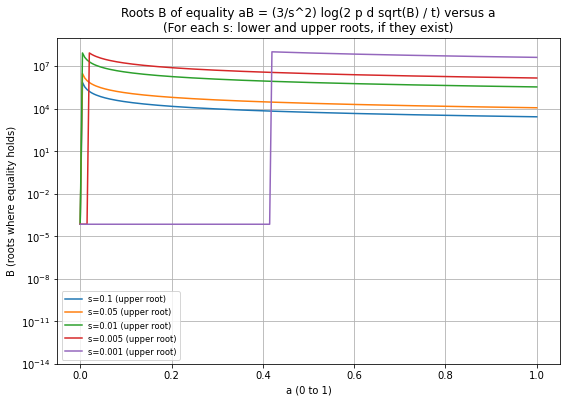

In [13]:
# Plot B vs a for different s values by numerically finding the roots of
#   f(B) = a*B - (3/s^2) * log( (2*p*d*sqrt(B))/t )
# The user should replace p, d, t and s_values with their own numbers.
# This cell will run here and display the plot.

import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------------
# EDIT THESE VALUES (user-provided)
p = 2.0
d = 3.0
t = 0.1
s_values = [0.1, 0.05, 0.01, 0.005, 0.001]   # example s values; replace with the s-values you want to plot
# ------------------------------

# grid for 'a' (x-axis)
a_grid = np.linspace(0.0, 1.0, 201)

# grid for B to search for sign changes (wide log-spaced grid)
B_grid = np.logspace(-12, 8, 4000)

def f_of_B(B, a, s):
    # ensure array handling; B>0 required
    return a * B - (3.0 / (s**2)) * np.log((2.0 * p * d * np.sqrt(B)) / t)

def find_roots_for_a(a, s):
    # evaluate f on grid and look for sign changes
    fvals = f_of_B(B_grid, a, s)
    roots = []
    # find intervals where sign changes or exactly zero
    prod = fvals[:-1] * fvals[1:]
    indices = np.where(prod <= 0)[0]
    # We'll attempt to refine up to 2 distinct positive roots.
    for idx in indices:
        low = B_grid[idx]
        high = B_grid[idx+1]
        f_low = fvals[idx]
        f_high = fvals[idx+1]
        # require that we have a valid sign change or exact zero
        if np.isnan(f_low) or np.isnan(f_high):
            continue
        if f_low == 0.0:
            root = low
            roots.append(root)
            continue
        if f_high == 0.0:
            root = high
            roots.append(root)
            continue
        if f_low * f_high > 0:
            continue
        # bisection refine
        lo, hi = low, high
        flo, fhi = f_low, f_high
        for _ in range(60):
            mid = 0.5*(lo+hi)
            fmid = f_of_B(mid, a, s)
            if fmid == 0:
                lo = hi = mid
                break
            if flo * fmid <= 0:
                hi = mid
                fhi = fmid
            else:
                lo = mid
                flo = fmid
        root = 0.5*(lo+hi)
        # avoid duplicates (within tolerance)
        if all(abs(root - r) > 1e-9 * max(1.0, r) for r in roots):
            roots.append(root)
        if len(roots) >= 2:
            break
    # sort roots if any
    roots.sort()
    return roots

# For each s, build arrays of lower and upper roots across a_grid
results = {}
for s in s_values:
    lower = np.full_like(a_grid, np.nan, dtype=float)
    upper = np.full_like(a_grid, np.nan, dtype=float)
    for i, a in enumerate(a_grid):
        roots = find_roots_for_a(a, s)
        if len(roots) == 1:
            # one root (tangent case) put it in both lower and upper
            lower[i] = roots[0]
            upper[i] = roots[0]
        elif len(roots) == 2:
            lower[i] = roots[0]
            upper[i] = roots[1]
        # else leave NaN (no real positive roots where equality holds)
    results[s] = (lower, upper)

# Plotting
plt.figure(figsize=(9,6))
for s in s_values:
    lower, upper = results[s]
    # plot upper and lower roots; lower as dashed, upper as solid
    # plt.plot(a_grid, lower, linestyle='--', label=f's={s} (lower root)')
    plt.plot(a_grid, upper, linestyle='-', label=f's={s} (upper root)')

plt.xlabel('a (0 to 1)')
plt.ylabel('B (roots where equality holds)')
plt.title('Roots B of equality aB = (3/s^2) log(2 p d sqrt(B) / t) versus a\n(For each s: lower and upper roots, if they exist)')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.yscale('log')  # B can vary many orders of magnitude; log scale is convenient
plt.ylim(bottom=1e-14, top=1e9)
plt.show()

# Give a short summary table of how many a values had two, one, or zero roots per s
summary = []
for s in s_values:
    lower, upper = results[s]
    n_two = np.sum(~np.isnan(lower) & ~np.isnan(upper) & (np.abs(lower-upper) > 1e-12))
    n_one = np.sum(~np.isnan(lower) & ~np.isnan(upper) & (np.abs(lower-upper) <= 1e-12))
    n_zero = a_grid.size - (n_two + n_one)
    summary.append((s, int(n_two), int(n_one), int(n_zero)))

# import pandas as pd
# df = pd.DataFrame(summary, columns=['s','#a with two roots','#a with one root','#a with no root'])
# import caas_jupyter_tools as cjt
# cjt.display_dataframe_to_user("roots-summary", df)


In [10]:
def compute_equation(a, B, p, d, delta, epsilon):
    numerator = 3 * math.log((2 * p * d * math.sqrt(B)) / delta)
    denominator = epsilon ** 2
    rhs = numerator / denominator
    lhs = a * B
    return lhs, rhs

In [11]:
lhs, rhs = compute_equation(0.5, 4000, 2.0, 3.0, delta=0.1, epsilon=0.01)
print(f"{lhs} <= {rhs}")
print(lhs<=rhs)

2000.0 <= 268035.4968849918
True
